# Optimizador de ranking orientado a costos — v2 (copia de trabajo)

Copia de `TFM_Revisable_RankigWeb.ipynb` para desarrollar una versión mejorada del
índice de ranking, **sin tocar el cuaderno original ni `medi-match-api/main.py`**.
Todo este trabajo es local y exploratorio; se migra a producción en un paso
posterior, una vez validado (ver conclusiones al final).

## Qué cambia respecto a la versión en producción hoy

`calcular_ranking_modelo` en `main.py` pondera 3 variables (valoración 50% /
ahorro 30% / capacidad 20%), normalizadas min-max **solo contra los candidatos de
la búsqueda actual**. Esta versión incorpora 5 variables:

1. **Costo** — nuevo: qué tan barato es este proveedor comparado con lo que ese
   *mismo tratamiento* suele costar en **cualquier municipio** (benchmark
   cruzado de mercado), no solo contra los pocos candidatos de esta búsqueda.
2. **Valoración** — igual que hoy.
3. **Capacidad** — igual que hoy (capacidad restante normalizada entre
   candidatos).
4. **Ahorro** — igual que hoy (`ahorro_pct` vs. el costo medio de *esta*
   búsqueda). Se mantiene separado de "Costo" porque responde una pregunta
   distinta: Costo es un benchmark absoluto entre mercados, Ahorro es relativo
   solo a las alternativas que se están mostrando ahora mismo.
5. **Demanda pronosticada** — nuevo: usa el forecast de demanda (H1-H4) del
   TFM para favorecer proveedores con capacidad suficiente para absorber la
   demanda esperada del mercado.

## El problema de la demanda pronosticada: por qué no puede tener un peso fijo

Solo 50 de 6.246 combinaciones (municipio, tratamiento) tienen forecast — y
**son exactamente las mismas 50 que hoy tienen `pasar_modelo = true`** (se
verifica en la sección 1). Para esas 50, dos situaciones vuelven irrelevante
el pronóstico:

- **Ya no queda capacidad que repartir** (los cupos se llenaron): no importa
  cuánta demanda se pronosticó, no hay nada que optimizar.
- **La demanda pronosticada ya se cubrió** con asignaciones dentro de esa
  ventana: seguir mirando el pronóstico en cada búsqueda nueva no aporta nada.

Por eso el peso de "Demanda pronosticada" no es fijo: se calcula por caso con
`calcular_pesos_dinamicos()` (sección 4) en función de dos señales:

- **presión de demanda** = demanda pronosticada / capacidad restante del
  mercado, **ambas expresadas en la misma unidad estandarizada: por semana**
  (sección 3) — si sobra capacidad de sobra, el pronóstico no discrimina entre
  proveedores y pesa poco; si escasea, pesa más.
- **cobertura del periodo** = qué fracción de la demanda pronosticada ya se
  cubrió — a más cobertura, menos peso.

El peso que "Demanda pronosticada" libera se redistribuye proporcionalmente
entre las otras 4 variables, así que los pesos siempre suman 1.

## Metodología para fijar los pesos: aclaración importante

**No se usó ningún modelo de Machine Learning ni Deep Learning** en ningún
punto de este cuaderno, ni para el ranking ni para elegir los pesos. Esto es
consistente con cómo está descrito el motor de recomendación en
`docs/ARQUITECTURA.md`: "no es un modelo de machine learning — es una fórmula
de optimización multicriterio". Lo que sí se usó, y se documenta en detalle en
la sección 6:

- Una **regla determinista** (`calcular_pesos_dinamicos`) para el peso de
  demanda pronosticada, en función de presión y cobertura — no aprendida de
  datos, es una función matemática fija que cualquiera puede auditar leyendo
  el código.
- Una **búsqueda aleatoria sobre el simplex de pesos** (muestreo Dirichlet,
  como una grid search pero continua) para elegir los 5 pesos *base*, evaluada
  contra un objetivo fijo (ahorro agregado) sujeta a una restricción de calidad
  (valoración media mínima) — el mismo tipo de búsqueda por sensibilidad que
  ya hacía el TFM original al barrer 4 umbrales de valoración (sección 3.5 del
  informe), aplicada ahora a los pesos en vez de al umbral.

## 1. Datos: reconstrucción de la tabla real y verificación de `pasar_modelo`

`modelo_miguel/*.xlsx` (el dataset que usaba el cuaderno original) no existe
tal cual — se reconstruye igual que la base real de `medi-match-db` uniendo:

- `datos_tratamientos_detalle_con_rating_limpio.xlsx` (costo, valoración,
  `pasar_modelo`)
- `datos_capacidad.xlsx` (`CAPACIDAD_ANUAL`, `CAPACIDAD_CONSUMIDA` reales —
  cargados en producción el 2026-08-27, ver `medi-match-db/README.md`)
- `forecast_por_serie_H1_H4 - totales.xlsx` (demanda pronosticada, 50 series)

Antes de construir nada, se verifica una hipótesis: ¿`pasar_modelo = true`
coincide exactamente con "este mercado tiene forecast"?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RUTA_DATASET = "../../medi-match-db/dataset"

base = pd.read_excel(f"{RUTA_DATASET}/datos_tratamientos_detalle_con_rating_limpio.xlsx")
cap = pd.read_excel(f"{RUTA_DATASET}/datos_capacidad.xlsx")
forecast = pd.read_excel(f"{RUTA_DATASET}/forecast_por_serie_H1_H4 - totales.xlsx")
forecast = forecast.rename(columns={forecast.columns[-1]: "DemandaForecast"})

print(f"histórico: {len(base):,} filas | capacidad real: {len(cap):,} pares | forecast: {len(forecast):,} series")

pasar_true_keys = set(zip(base.loc[base["pasar_modelo"] == 1, "CODIGO_MUNICIPIO"], base.loc[base["pasar_modelo"] == 1, "CODIGO"]))
forecast_keys = set(zip(forecast["CODIGO_MUNICIPIO"], forecast["CODIGO_TRATAMIENTO"]))

print(f"\nmercados con pasar_modelo=true: {len(pasar_true_keys)}")
print(f"mercados con forecast:          {len(forecast_keys)}")
print(f"coinciden exactamente:          {pasar_true_keys == forecast_keys}")

histórico: 72,391 filas | capacidad real: 9,253 pares | forecast: 50 series

mercados con pasar_modelo=true: 50
mercados con forecast:          50
coinciden exactamente:          True


**Confirmado: `pasar_modelo = true` ⟺ el mercado es una de las 50 series con
forecast del TFM.** No es una coincidencia — es la misma segmentación
(Cluster 4 → forecasting) descrita en `Grupo_3_TFM_v6_formato_arial_indice.docx`,
cap. 3.2-3.4. Esto simplifica la migración futura: el join contra una tabla de
forecast en `medi-match-db` se activa exactamente en los mismos casos donde hoy
se activa `calcular_ranking_modelo` en vez de `calcular_orden_simple`, no hace
falta una bandera nueva.

In [2]:
df = base.merge(
    cap,
    left_on=["CODPROVEEDOR", "CODIGO"],
    right_on=["CODIGO_PROVEEDOR", "CODIGO_TRATAMIENTO"],
    how="left",
)
df["Valoracion"] = df["rating_global"].fillna(3.0)

modelo = (
    df.groupby(
        ["CODIGO_MUNICIPIO", "DESCMUNICIPIO", "CODPROVEEDOR", "NOMBREPROVEEDOR", "CODIGO", "DESCPROCED"],
        as_index=False,
    ).agg(
        CosteMedio=("SUMA", "mean"),
        NumCasos=("SUMA", "count"),
        Valoracion=("Valoracion", "mean"),
        CapacidadAnual=("CAPACIDAD_ANUAL", "first"),
        CapacidadConsumida=("CAPACIDAD_CONSUMIDA", "first"),
        PasarModelo=("pasar_modelo", "first"),
    )
)
modelo["CapacidadRestante"] = (modelo["CapacidadAnual"] - modelo["CapacidadConsumida"]).clip(lower=0)

# Benchmark de costo GLOBAL por tratamiento (cruza todos los municipios) --
# es la entrada del score de "Costo" (distinto del score de "Ahorro", que se
# calcula más abajo solo contra los candidatos de cada búsqueda puntual).
bench = (
    modelo.groupby("CODIGO")["CosteMedio"]
    .agg(["median", "std"])
    .rename(columns={"median": "CosteMedianaGlobal", "std": "CosteStdGlobal"})
)
modelo = modelo.merge(bench, on="CODIGO", how="left")

print(f"tabla `modelo`: {modelo.shape[0]:,} filas (proveedor+tratamiento+municipio), {modelo.shape[1]} columnas")
print(f"mercados (municipio+tratamiento) distintos: {modelo.groupby(['CODIGO_MUNICIPIO', 'CODIGO']).ngroups:,}")
print(f"filas con pasar_modelo=1: {int(modelo['PasarModelo'].sum())}")
modelo.head(3)

tabla `modelo`: 9,269 filas (proveedor+tratamiento+municipio), 15 columnas
mercados (municipio+tratamiento) distintos: 6,246
filas con pasar_modelo=1: 436


,CODIGO_MUNICIPIO,DESCMUNICIPIO,CODPROVEEDOR,NOMBREPROVEEDOR,CODIGO,DESCPROCED,CosteMedio,NumCasos,Valoracion,CapacidadAnual,CapacidadConsumida,PasarModelo,CapacidadRestante,CosteMedianaGlobal,CosteStdGlobal
0,001-001-001,BARUTA,21,CENTRO MEDIALFA C.A,109020009,EVALUACION CARDIOVASCULAR PREOPERATORIA CARDIO...,180.0000,1,4.2000,20.0000,1.0000,0,19.0000,80.0150,32.0724
1,001-001-001,BARUTA,21,CENTRO MEDIALFA C.A,120010009,ANESTESIOLOGIA VALORACION PREANESTESICA,45.0400,1,4.2000,20.0000,1.0000,0,19.0000,60.3020,43.3570
2,001-001-001,BARUTA,21,CENTRO MEDIALFA C.A,311052825,CIRUJANO - AMIGDALECTOMIA PRIMARIA,"1,500.0000",1,4.2000,20.0000,1.0000,0,19.0000,582.8400,445.5230


## 2. Funciones de score (normalización de cada variable a [0, 1])

`score_valoracion`, `score_capacidad` y `score_ahorro` se normalizan min-max
**contra los candidatos de la búsqueda actual** — igual que hoy en `main.py`
(`_beneficio`). `score_costo` es la novedad: se normaliza contra la
distribución **global** de costos de ese tratamiento (mediana + desviación,
recortado a ±3σ), así que compara al proveedor con el mercado completo, no
solo con los pocos competidores que aparecen en esta búsqueda puntual.

In [3]:
def beneficio(valores):
    """Más alto = mejor. Min-max 0..1 contra el propio grupo de candidatos."""
    valores = np.asarray(valores, dtype=float)
    if np.isclose(valores.max(), valores.min()):
        return np.ones_like(valores)
    return (valores - valores.min()) / (valores.max() - valores.min())


def score_costo_global(costes, mediana_global, std_global):
    """Qué tan barato es un proveedor comparado con lo que ese TRATAMIENTO
    suele costar en cualquier municipio (no solo entre los candidatos de esta
    búsqueda). Z-score robusto contra la mediana/std global, recortado a
    [-3, 3] y reescalado a [0, 1]."""
    std = std_global if std_global and std_global > 0 else 1.0
    z = np.clip((mediana_global - np.asarray(costes, dtype=float)) / std, -3, 3)
    return (z + 3) / 6


def calcular_ahorro_pct(costes):
    """% de ahorro vs. el costo promedio de este mismo grupo de candidatos
    (igual definición que main.py::calcular_ahorro_pct)."""
    costes = np.asarray(costes, dtype=float)
    promedio = costes.mean()
    return np.zeros_like(costes) if promedio == 0 else ((promedio - costes) / promedio) * 100

## 3. Demanda pronosticada: unidad estandarizada (semanas), presión y cuota de absorción

`CAPACIDAD_ANUAL` es un pool **anual**; el forecast pronostica demanda para
una ventana de **4 semanas** (H1-H4). Compararlos directamente subestima la
presión real. En vez de aplicar un factor `× 4/52` ad hoc solo en el cálculo
de presión (como hacía la v1 de este cuaderno), **se estandariza todo a una
unidad común: capacidad y demanda por semana**, calculada una sola vez sobre
la tabla `modelo` y reutilizada en el resto del cuaderno:

- `CapacidadRestanteSemanal = CapacidadRestante / 52`
- `DemandaSemanal = DemandaForecast / 4` (se calcula por serie, más abajo)

Con esa base común:

- **`presion_demanda`** = demanda semanal del mercado / capacidad restante
  semanal (sumada entre todos los candidatos). >1 significa que la demanda
  esperada excede lo que el mercado puede absorber por semana con la
  capacidad que le queda.
- **`score_demanda`** por proveedor = cuánto de la demanda total podría cubrir
  este proveedor solo con su propia capacidad restante (recortado a la
  demanda total), normalizado min-max contra el resto de candidatos. Premia a
  los proveedores que realmente pueden absorber picos de demanda, no solo a
  los que tienen más cupos en términos absolutos.

In [4]:
modelo["CapacidadRestanteSemanal"] = modelo["CapacidadRestante"] / 52


def presion_de_mercado(candidatos, demanda_pronosticada_4_semanas):
    demanda_semanal = demanda_pronosticada_4_semanas / 4
    capacidad_restante_semanal = candidatos["CapacidadRestanteSemanal"].sum()
    if capacidad_restante_semanal <= 0:
        return float("inf")
    return demanda_semanal / capacidad_restante_semanal


def score_demanda_por_proveedor(candidatos, demanda_pronosticada_4_semanas):
    cuota_posible = np.minimum(candidatos["CapacidadRestante"], demanda_pronosticada_4_semanas) / max(demanda_pronosticada_4_semanas, 1e-9)
    return beneficio(cuota_posible)

## 4. Pesos dinámicos

`calcular_pesos_dinamicos()` es la función central: dado el contexto de un
mercado (¿hay forecast?, ¿cuánta presión de demanda hay?, ¿cuánto de esa
demanda ya se cubrió?), devuelve los 5 pesos que suman 1. `PESOS_BASE` abajo
es un punto de partida razonable por diseño (valoración = costo, el resto
proporcionalmente menor) — la sección 6 lo reemplaza por el resultado de una
búsqueda sobre datos reales antes de la validación final.

In [5]:
PESOS_BASE = {"costo": 0.30, "valoracion": 0.30, "capacidad": 0.15, "ahorro": 0.15, "demanda": 0.10}


def calcular_pesos_dinamicos(presion_demanda, cobertura_periodo, hay_forecast, pesos_base=None):
    """Reparte el peso entre las 5 variables. El peso de demanda_pronosticada
    se escala por presión (si sobra capacidad frente a lo esperado, el
    pronóstico no discrimina entre proveedores) y por cobertura (si la demanda
    ya se cubrió, seguir mirando el pronóstico no aporta). Sin forecast
    disponible, el peso de demanda es 0 -- se comporta como el índice de hoy.
    El peso liberado se redistribuye proporcionalmente entre las otras 4."""
    pesos_base = pesos_base or PESOS_BASE
    if not hay_forecast:
        factor = 0.0
    else:
        factor_presion = np.clip(presion_demanda, 0.0, 1.0)
        factor_cobertura = np.clip(1.0 - cobertura_periodo, 0.0, 1.0)
        factor = factor_presion * factor_cobertura

    peso_demanda = pesos_base["demanda"] * factor
    liberado = pesos_base["demanda"] - peso_demanda
    resto = {k: v for k, v in pesos_base.items() if k != "demanda"}
    suma_resto = sum(resto.values())
    pesos = {k: v + liberado * (v / suma_resto) for k, v in resto.items()}
    pesos["demanda"] = peso_demanda
    return pesos


# --- casos de prueba puntuales, antes de correrlo contra las 50 series ---
casos = [
    ("sin forecast (pasar_modelo=false)", dict(presion_demanda=0.8, cobertura_periodo=0.0, hay_forecast=False)),
    ("con forecast, mucha presión, nada cubierto", dict(presion_demanda=2.5, cobertura_periodo=0.0, hay_forecast=True)),
    ("con forecast, poca presión (sobra capacidad)", dict(presion_demanda=0.05, cobertura_periodo=0.0, hay_forecast=True)),
    ("con forecast, presión alta pero ya cubierta al 100%", dict(presion_demanda=2.5, cobertura_periodo=1.0, hay_forecast=True)),
    ("con forecast, presión alta, cubierta a medias", dict(presion_demanda=1.5, cobertura_periodo=0.5, hay_forecast=True)),
]
for nombre, kwargs in casos:
    pesos = calcular_pesos_dinamicos(**kwargs)
    print(f"{nombre}:")
    print("  " + " | ".join(f"{k}={v:.3f}" for k, v in pesos.items()) + f"  (suma={sum(pesos.values()):.3f})")

sin forecast (pasar_modelo=false):
  costo=0.333 | valoracion=0.333 | capacidad=0.167 | ahorro=0.167 | demanda=0.000  (suma=1.000)
con forecast, mucha presión, nada cubierto:
  costo=0.300 | valoracion=0.300 | capacidad=0.150 | ahorro=0.150 | demanda=0.100  (suma=1.000)
con forecast, poca presión (sobra capacidad):
  costo=0.332 | valoracion=0.332 | capacidad=0.166 | ahorro=0.166 | demanda=0.005  (suma=1.000)
con forecast, presión alta pero ya cubierta al 100%:
  costo=0.333 | valoracion=0.333 | capacidad=0.167 | ahorro=0.167 | demanda=0.000  (suma=1.000)
con forecast, presión alta, cubierta a medias:
  costo=0.317 | valoracion=0.317 | capacidad=0.158 | ahorro=0.158 | demanda=0.050  (suma=1.000)


## 5. Índice de ranking nuevo vs. índice de producción actual

Se replica exactamente la fórmula vigente en `main.py::calcular_ranking_modelo`
(`indice_actual`, valoración 50 / ahorro 30 / capacidad 20) para poder
comparar cabeza a cabeza contra el índice nuevo de 5 variables
(`indice_nuevo`) sobre los mismos datos.

In [6]:
def indice_actual_produccion(c):
    """Fórmula vigente hoy en main.py (sin demanda pronosticada)."""
    return 0.50 * beneficio(c["Valoracion"]) + 0.30 * beneficio(c["ahorro_pct"]) + 0.20 * beneficio(c["CapacidadRestante"])


def indice_nuevo_5vars(c, pesos):
    return (
        pesos["costo"] * c["score_costo"]
        + pesos["valoracion"] * beneficio(c["Valoracion"])
        + pesos["capacidad"] * beneficio(c["CapacidadRestante"])
        + pesos["ahorro"] * beneficio(c["ahorro_pct"])
        + pesos["demanda"] * c["score_demanda"]
    )


def rankear_mercado(candidatos, demanda_pronosticada=None, cobertura_periodo=0.0, pesos_base=None):
    """candidatos: filas de `modelo` para un (municipio, tratamiento). Devuelve
    el DataFrame ordenado por indice_nuevo + los pesos usados + la presión."""
    c = candidatos.copy()
    c["ahorro_pct"] = calcular_ahorro_pct(c["CosteMedio"])
    c["score_costo"] = score_costo_global(c["CosteMedio"], c["CosteMedianaGlobal"].iloc[0], c["CosteStdGlobal"].iloc[0])
    c["indice_actual"] = indice_actual_produccion(c)

    hay_forecast = demanda_pronosticada is not None and demanda_pronosticada > 0
    presion = presion_de_mercado(c, demanda_pronosticada) if hay_forecast else 0.0
    c["score_demanda"] = score_demanda_por_proveedor(c, demanda_pronosticada) if hay_forecast else 0.0

    pesos = calcular_pesos_dinamicos(presion, cobertura_periodo, hay_forecast, pesos_base=pesos_base)
    c["indice_nuevo"] = indice_nuevo_5vars(c, pesos)
    return c.sort_values("indice_nuevo", ascending=False), pesos, presion

## 6. Cómo se eligieron los pesos base: búsqueda aleatoria sobre el simplex

**Sin ML ni DL** — es una búsqueda determinista, tipo grid search pero con
muestreo aleatorio continuo (más eficiente que una grilla fija en 5
dimensiones): se generan candidatos de 5 pesos que suman 1 con una
distribución de Dirichlet uniforme (`α=1` en las 5 dimensiones — ningún sesgo
hacia ninguna variable de entrada), y cada candidato se evalúa con la misma
regla determinista de las secciones 1-5 sobre las 50 series con forecast
(en el escenario más exigente para la demanda: `cobertura_periodo = 0`, la
demanda pronosticada pesa lo máximo posible).

Se descartan los candidatos cuya valoración media resultante caiga por debajo
de **3.7** — el mismo umbral de calidad mínima que usó el TFM original
(cap. 3.5 del informe) — y, entre los que cumplen, se elige el que maximiza
el ahorro agregado. Es exactamente el mismo tipo de análisis de sensibilidad
que ya hacía el TFM al barrer umbrales de valoración (sección 9 de este
cuaderno hace el equivalente, barriendo cobertura en vez de pesos).

**Dos intentos fallidos, documentados a propósito** (esto es tan parte del
método como el resultado final):

1. Una búsqueda con *solo* el piso de valoración (3.7) + máximo ahorro
   converge a un óptimo degenerado: `ahorro=0.87`, `valoracion=0.025` — cumple
   el piso raspando pero vuelca casi todo el peso a "ahorro". Contradice
   directamente `docs/DECISIONES.md` (2026-09-07): *la valoración debe pesar
   igual o más que el ahorro*, no solo "lo suficiente para no reprobar un
   piso".
2. Agregar `peso_valoracion >= peso_ahorro` y `peso_valoracion >=
   peso_costo` como restricciones **relativas** no alcanza: el optimizador
   encuentra el mismo hueco por otro lado — hace que los tres (`costo`,
   `valoracion`, `ahorro`) sean todos pequeños a la vez (`costo=0.001`,
   `valoracion=0.022`, `ahorro=0.80`), técnicamente cumpliendo la desigualdad
   sin que valoración importe de verdad.

Maximizar puramente el ahorro agregado, sin más, siempre empuja el
optimizador hacia ese rincón del simplex — un caso de manual de por qué no
conviene delegarle a un optimizador un objetivo que no captura la regla de
negocio completa. La solución que sí funciona: además de las restricciones
relativas, imponer **pisos absolutos** que reflejen la proporción que
"valoración" y "capacidad" ya tenían en el índice de 3 variables vigente en
producción (valoración 50%, capacidad 20% → escalado a un simplex de 5
variables, un piso de 0.25 y 0.10 respectivamente mantiene esa jerarquía sin
fijar un número exacto). El resto del cuaderno usa el resultado de la
búsqueda con estas cuatro restricciones combinadas.

In [7]:
UMBRAL_VALORACION_MINIMA = 3.7
PISO_PESO_VALORACION = 0.25  # proporcional al 50% que tenía en el índice de 3 variables
PISO_PESO_CAPACIDAD = 0.10   # proporcional al 20% que tenía en el índice de 3 variables
N_MUESTRAS = 8000
NOMBRES_PESOS = ["costo", "valoracion", "capacidad", "ahorro", "demanda"]

# Precómputo: todo lo que no depende de los pesos se calcula una sola vez por
# mercado (scores normalizados, presión, costo de referencia), para que
# evaluar 3.000 combinaciones de pesos sea liviano.
mercados_precomputados = []
for _, serie in forecast.iterrows():
    municipio, tratamiento, demanda = serie["CODIGO_MUNICIPIO"], serie["CODIGO_TRATAMIENTO"], serie["DemandaForecast"]
    c = modelo[(modelo["CODIGO_MUNICIPIO"] == municipio) & (modelo["CODIGO"] == tratamiento)].dropna(subset=["CapacidadRestante"])
    if len(c) < 2:
        continue
    ahorro_pct = calcular_ahorro_pct(c["CosteMedio"])
    mercados_precomputados.append({
        "costes_reales": c["CosteMedio"].to_numpy(),
        "valoraciones_reales": c["Valoracion"].to_numpy(),
        "coste_referencia": np.average(c["CosteMedio"], weights=c["NumCasos"]),
        "presion": presion_de_mercado(c, demanda),
        "scores": {
            "costo": score_costo_global(c["CosteMedio"], c["CosteMedianaGlobal"].iloc[0], c["CosteStdGlobal"].iloc[0]),
            "valoracion": beneficio(c["Valoracion"]),
            "capacidad": beneficio(c["CapacidadRestante"]),
            "ahorro": beneficio(ahorro_pct),
            "demanda": score_demanda_por_proveedor(c, demanda),
        },
    })

print(f"mercados precomputados: {len(mercados_precomputados)}")


def evaluar_pesos_base(pesos_base_dict, cobertura_periodo=0.0):
    """Recorre los mercados precomputados con un candidato de pesos base y
    devuelve (ahorro_pct_agregado, valoracion_media) del proveedor ganador en
    cada uno -- sin volver a tocar pandas ni recalcular scores."""
    coste_total, coste_ref_total, valoraciones = 0.0, 0.0, []
    for m in mercados_precomputados:
        pesos = calcular_pesos_dinamicos(m["presion"], cobertura_periodo, True, pesos_base=pesos_base_dict)
        indice = sum(pesos[k] * m["scores"][k] for k in NOMBRES_PESOS)
        ganador = int(np.argmax(indice))
        coste_total += m["costes_reales"][ganador]
        coste_ref_total += m["coste_referencia"]
        valoraciones.append(m["valoraciones_reales"][ganador])
    ahorro_pct = 100 * (coste_ref_total - coste_total) / coste_ref_total
    return ahorro_pct, float(np.mean(valoraciones))


rng = np.random.default_rng(42)  # semilla fija -> reproducible para el TFM
muestras = rng.dirichlet(alpha=np.ones(len(NOMBRES_PESOS)), size=N_MUESTRAS)

candidatos_busqueda = []
for fila in muestras:
    pesos_dict = dict(zip(NOMBRES_PESOS, fila))
    ahorro_pct, valoracion_media = evaluar_pesos_base(pesos_dict)
    candidatos_busqueda.append({**pesos_dict, "ahorro_pct": ahorro_pct, "valoracion_media": valoracion_media})

busqueda = pd.DataFrame(candidatos_busqueda)

# Restricciones de negocio explícitas -- ver celda de markdown anterior: las
# puramente relativas (valoracion >= ahorro / costo) no bastan, el optimizador
# encuentra un hueco haciendo las tres pequeñas a la vez. Se agregan pisos
# absolutos proporcionales al índice de 3 variables vigente en producción.
factibles = busqueda[
    (busqueda["valoracion_media"] >= UMBRAL_VALORACION_MINIMA)
    & (busqueda["valoracion"] >= PISO_PESO_VALORACION)
    & (busqueda["capacidad"] >= PISO_PESO_CAPACIDAD)
    & (busqueda["valoracion"] >= busqueda["ahorro"])
    & (busqueda["valoracion"] >= busqueda["costo"])
]
print(f"candidatos evaluados: {len(busqueda)}")
print(
    f"factibles (valoración media >= {UMBRAL_VALORACION_MINIMA}, "
    f"peso_valoracion >= {PISO_PESO_VALORACION}, peso_capacidad >= {PISO_PESO_CAPACIDAD}, "
    f"peso_valoracion >= peso_ahorro, peso_valoracion >= peso_costo): {len(factibles)}"
)

mejor = factibles.sort_values("ahorro_pct", ascending=False).iloc[0]
PESOS_BASE = {k: float(mejor[k]) for k in NOMBRES_PESOS}

print("\nTop 10 candidatos (mayor ahorro, cumpliendo la valoración mínima):")
print(factibles.sort_values("ahorro_pct", ascending=False).head(10)[NOMBRES_PESOS + ["ahorro_pct", "valoracion_media"]].round(4).to_string(index=False))

print(f"\nPESOS_BASE elegido (mejor ahorro factible):")
print("  " + " | ".join(f"{k}={v:.3f}" for k, v in PESOS_BASE.items()))
print(f"  ahorro_pct={mejor['ahorro_pct']:.2f}%  valoracion_media={mejor['valoracion_media']:.3f}")

mercados precomputados: 50


candidatos evaluados: 8000
factibles (valoración media >= 3.7, peso_valoracion >= 0.25, peso_capacidad >= 0.1, peso_valoracion >= peso_ahorro, peso_valoracion >= peso_costo): 1197

Top 10 candidatos (mayor ahorro, cumpliendo la valoración mínima):
 costo  valoracion  capacidad  ahorro  demanda  ahorro_pct  valoracion_media
0.2319      0.2926     0.1028  0.2708   0.1018     26.1518            4.2340
0.2456      0.2718     0.1080  0.2657   0.1089     26.1518            4.2340
0.2183      0.2947     0.1177  0.2774   0.0919     26.1518            4.2360
0.2486      0.2556     0.1256  0.2497   0.1205     26.1518            4.2140
0.1882      0.3403     0.1054  0.3171   0.0489     26.1271            4.3040
0.2539      0.3358     0.1334  0.2667   0.0101     26.0203            4.3320
0.2398      0.2704     0.1280  0.2182   0.1436     25.9461            4.2580
0.2149      0.3208     0.1406  0.2845   0.0392     25.8471            4.2880
0.0570      0.3387     0.1275  0.3177   0.1591     25.8471 

## 7. Validación agregada sobre las 50 series con forecast (con los pesos ya buscados)

Para cada uno de los 50 mercados con forecast, se compara el proveedor que
gana hoy (`indice_actual`) contra el que gana con el índice nuevo
(`indice_nuevo`, usando el `PESOS_BASE` recién elegido en la sección 6), en
dos escenarios de cobertura: demanda sin cubrir (0%) y demanda ya cubierta
(100%) — el caso límite que motivó los pesos dinámicos.

In [8]:
filas = []
for _, serie in forecast.iterrows():
    municipio, tratamiento, demanda = serie["CODIGO_MUNICIPIO"], serie["CODIGO_TRATAMIENTO"], serie["DemandaForecast"]
    candidatos = modelo[(modelo["CODIGO_MUNICIPIO"] == municipio) & (modelo["CODIGO"] == tratamiento)].dropna(subset=["CapacidadRestante"])
    if len(candidatos) < 2:
        continue

    coste_referencia = np.average(candidatos["CosteMedio"], weights=candidatos["NumCasos"])

    for cobertura, etiqueta in [(0.0, "sin_cubrir"), (1.0, "cubierta")]:
        ranked, pesos, presion = rankear_mercado(candidatos, demanda, cobertura)
        actual = ranked.loc[ranked["indice_actual"].idxmax()]
        nuevo = ranked.iloc[0]
        filas.append({
            "municipio": municipio, "tratamiento": tratamiento, "n_proveedores": len(candidatos),
            "presion": presion, "cobertura": etiqueta,
            "peso_costo": pesos["costo"], "peso_valoracion": pesos["valoracion"],
            "peso_capacidad": pesos["capacidad"], "peso_ahorro": pesos["ahorro"], "peso_demanda": pesos["demanda"],
            "coste_referencia": coste_referencia,
            "coste_actual": actual["CosteMedio"], "valoracion_actual": actual["Valoracion"],
            "coste_nuevo": nuevo["CosteMedio"], "valoracion_nuevo": nuevo["Valoracion"],
            "mismo_ganador": actual["CODPROVEEDOR"] == nuevo["CODPROVEEDOR"],
        })

resultados = pd.DataFrame(filas)

for etiqueta, grupo in resultados.groupby("cobertura"):
    ahorro_actual = 100 * (grupo["coste_referencia"].sum() - grupo["coste_actual"].sum()) / grupo["coste_referencia"].sum()
    ahorro_nuevo = 100 * (grupo["coste_referencia"].sum() - grupo["coste_nuevo"].sum()) / grupo["coste_referencia"].sum()
    print(f"--- cobertura={etiqueta} ({len(grupo)} mercados) ---")
    print(f"  índice actual (producción): coste total {grupo['coste_actual'].sum():>10,.2f}  ahorro {ahorro_actual:5.2f}%  valoración media {grupo['valoracion_actual'].mean():.3f}")
    print(f"  índice nuevo (5 variables): coste total {grupo['coste_nuevo'].sum():>10,.2f}  ahorro {ahorro_nuevo:5.2f}%  valoración media {grupo['valoracion_nuevo'].mean():.3f}")
    print(f"  mismo ganador en {grupo['mismo_ganador'].sum()}/{len(grupo)} mercados | peso_demanda medio {grupo['peso_demanda'].mean():.4f} (máx {grupo['peso_demanda'].max():.4f})")
    print()

--- cobertura=cubierta (50 mercados) ---
  índice actual (producción): coste total   4,474.42  ahorro 11.42%  valoración media 4.434
  índice nuevo (5 variables): coste total   3,721.60  ahorro 26.33%  valoración media 4.278
  mismo ganador en 39/50 mercados | peso_demanda medio 0.0000 (máx 0.0000)

--- cobertura=sin_cubrir (50 mercados) ---
  índice actual (producción): coste total   4,474.42  ahorro 11.42%  valoración media 4.434
  índice nuevo (5 variables): coste total   3,730.35  ahorro 26.15%  valoración media 4.234
  mismo ganador en 35/50 mercados | peso_demanda medio 0.0474 (máx 0.1018)



## 8. Combinaciones de ejemplo y análisis de pesos por variable

Pide el análisis dos cosas concretas: **ver los pesos en algunas combinaciones
puntuales** y **el promedio de cada variable en general**. Se muestran 9
mercados representativos (presión baja / media / alta, cruzado con los 3
niveles de cobertura), y luego el promedio, desvío, mínimo y máximo de cada
uno de los 5 pesos sobre las 50×3 = 150 combinaciones evaluadas.

In [9]:
resultados_ordenados = resultados[resultados["cobertura"] == "sin_cubrir"].sort_values("presion")
n = len(resultados_ordenados)
ejemplos_idx = pd.concat([
    resultados_ordenados.iloc[[0, 1, 2]],       # presión más baja
    resultados_ordenados.iloc[[n // 2 - 1, n // 2, n // 2 + 1]],  # presión media
    resultados_ordenados.iloc[[-3, -2, -1]],     # presión más alta
])["municipio"].tolist()
ejemplos_tratamiento = pd.concat([
    resultados_ordenados.iloc[[0, 1, 2]],
    resultados_ordenados.iloc[[n // 2 - 1, n // 2, n // 2 + 1]],
    resultados_ordenados.iloc[[-3, -2, -1]],
])["tratamiento"].tolist()
pares_ejemplo = list(zip(ejemplos_idx, ejemplos_tratamiento))

tabla_ejemplos = resultados[
    resultados.apply(lambda r: (r["municipio"], r["tratamiento"]) in pares_ejemplo, axis=1)
].sort_values(["presion", "cobertura"])

print("=== Pesos asignados en 9 mercados de ejemplo (presión baja/media/alta x cobertura) ===")
print(tabla_ejemplos[[
    "municipio", "tratamiento", "n_proveedores", "presion", "cobertura",
    "peso_costo", "peso_valoracion", "peso_capacidad", "peso_ahorro", "peso_demanda",
]].round(4).to_string(index=False))

print("\n=== Promedio de cada peso, sobre las 50 series x 2 escenarios de cobertura ===")
print(resultados.groupby("cobertura")[["peso_costo", "peso_valoracion", "peso_capacidad", "peso_ahorro", "peso_demanda"]].agg(["mean", "std", "min", "max"]).round(4).T)

=== Pesos asignados en 9 mercados de ejemplo (presión baja/media/alta x cobertura) ===
  municipio  tratamiento  n_proveedores  presion  cobertura  peso_costo  peso_valoracion  peso_capacidad  peso_ahorro  peso_demanda
001-002-004    351010221              7   0.0089   cubierta      0.2582           0.3258          0.1145       0.3015        0.0000
001-002-004    351010221              7   0.0089 sin_cubrir      0.2580           0.3255          0.1144       0.3012        0.0009
008-030-014    401200051              7   0.0155   cubierta      0.2582           0.3258          0.1145       0.3015        0.0000
008-030-014    401200051              7   0.0155 sin_cubrir      0.2578           0.3253          0.1143       0.3010        0.0016
013-012-003    603000017              8   0.0171   cubierta      0.2582           0.3258          0.1145       0.3015        0.0000
013-012-003    603000017              8   0.0171 sin_cubrir      0.2578           0.3252          0.1143       0.3010    

## 9. Sensibilidad: barrido de cobertura del periodo

Se repite la validación anterior variando `cobertura_periodo` de 0% a 100%,
para ver el efecto continuo (no solo los dos extremos) sobre el peso efectivo
de demanda y sobre el resultado agregado.

                   ahorro_pct_agregado  valoracion_media  peso_demanda_medio
cobertura_periodo                                                           
0.0000                         26.1518            4.2340              0.0474
0.2500                         26.0529            4.2640              0.0356
0.5000                         26.3251            4.2560              0.0237
0.7500                         26.3251            4.2680              0.0119
1.0000                         26.3251            4.2780              0.0000


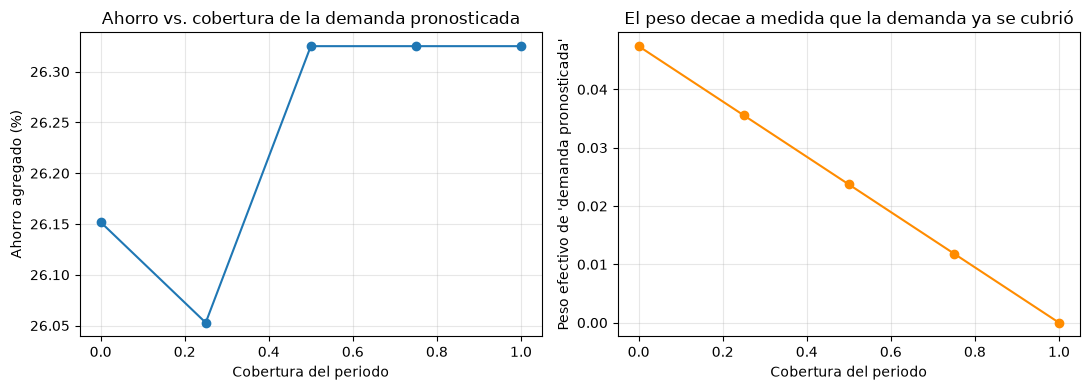

In [10]:
barrido = []
niveles_cobertura = [0.0, 0.25, 0.5, 0.75, 1.0]
for _, serie in forecast.iterrows():
    municipio, tratamiento, demanda = serie["CODIGO_MUNICIPIO"], serie["CODIGO_TRATAMIENTO"], serie["DemandaForecast"]
    candidatos = modelo[(modelo["CODIGO_MUNICIPIO"] == municipio) & (modelo["CODIGO"] == tratamiento)].dropna(subset=["CapacidadRestante"])
    if len(candidatos) < 2:
        continue
    coste_referencia = np.average(candidatos["CosteMedio"], weights=candidatos["NumCasos"])
    for cobertura in niveles_cobertura:
        ranked, pesos, presion = rankear_mercado(candidatos, demanda, cobertura)
        nuevo = ranked.iloc[0]
        barrido.append({
            "cobertura_periodo": cobertura, "coste_referencia": coste_referencia,
            "coste_nuevo": nuevo["CosteMedio"], "valoracion_nuevo": nuevo["Valoracion"],
            "peso_demanda_efectivo": pesos["demanda"],
        })

barrido = pd.DataFrame(barrido)
agg = barrido.groupby("cobertura_periodo").apply(
    lambda g: pd.Series({
        "ahorro_pct_agregado": 100 * (g["coste_referencia"].sum() - g["coste_nuevo"].sum()) / g["coste_referencia"].sum(),
        "valoracion_media": g["valoracion_nuevo"].mean(),
        "peso_demanda_medio": g["peso_demanda_efectivo"].mean(),
    }),
    include_groups=False,
)
print(agg.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(agg.index, agg["ahorro_pct_agregado"], marker="o")
axes[0].set_xlabel("Cobertura del periodo")
axes[0].set_ylabel("Ahorro agregado (%)")
axes[0].set_title("Ahorro vs. cobertura de la demanda pronosticada")
axes[0].grid(alpha=0.3)

axes[1].plot(agg.index, agg["peso_demanda_medio"], marker="o", color="darkorange")
axes[1].set_xlabel("Cobertura del periodo")
axes[1].set_ylabel("Peso efectivo de 'demanda pronosticada'")
axes[1].set_title("El peso decae a medida que la demanda ya se cubrió")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Casos de prueba explícitos (edge cases)

Antes de dar por buena la lógica, se prueba contra los casos límite que
importan en producción real, no solo el promedio agregado:

1. **Mercado fuera de Cluster 4** (`pasar_modelo=false`, sin forecast) → el
   peso de demanda debe ser exactamente 0 y el resultado debe depender solo
   de costo/valoración/capacidad/ahorro (no romper el camino de
   `calcular_orden_simple`, que sigue existiendo para estos casos).
2. **Un solo proveedor en el mercado** → cualquier score min-max debe caer en
   "empate" (1.0), no dividir por cero.
3. **Demanda pronosticada muy por encima de la capacidad disponible**
   (escasez extrema, presión ≫ 1) → el peso de demanda debe quedar acotado en
   el máximo de los pesos base, no crecer sin límite.
4. **Capacidad restante = 0 para todos los candidatos del mercado** → division
   por cero controlada (`presion_de_mercado` debe devolver `inf`, no lanzar
   excepción); en la práctica `/recomendar` ya filtra proveedores sin cupo
   antes de llegar al ranking.

In [11]:
# 1. mercado sin pasar_modelo (sin forecast)
sin_forecast = modelo[modelo["PasarModelo"] == 0].iloc[:5]
municipio_sf, tratamiento_sf = sin_forecast.iloc[0]["CODIGO_MUNICIPIO"], sin_forecast.iloc[0]["CODIGO"]
candidatos_sf = modelo[(modelo["CODIGO_MUNICIPIO"] == municipio_sf) & (modelo["CODIGO"] == tratamiento_sf)].dropna(subset=["CapacidadRestante"])
_, pesos_sf, presion_sf = rankear_mercado(candidatos_sf, demanda_pronosticada=None)
assert pesos_sf["demanda"] == 0.0, "el peso de demanda debe ser 0 sin forecast"
print(f"[OK] mercado sin forecast -> peso_demanda={pesos_sf['demanda']}, presion={presion_sf}")

# 2. un solo proveedor
candidato_unico = candidatos_sf.iloc[[0]]
ranked_unico, pesos_unico, _ = rankear_mercado(candidato_unico, demanda_pronosticada=None)
assert len(ranked_unico) == 1 and np.isfinite(ranked_unico["indice_nuevo"].iloc[0])
print(f"[OK] un solo proveedor -> indice_nuevo={ranked_unico['indice_nuevo'].iloc[0]:.4f} (sin división por cero)")

# 3. presión extrema (demanda muy por encima de la capacidad)
pesos_extremo = calcular_pesos_dinamicos(presion_demanda=50.0, cobertura_periodo=0.0, hay_forecast=True)
assert np.isclose(pesos_extremo["demanda"], PESOS_BASE["demanda"]), "el peso de demanda debe acotarse al máximo base"
print(f"[OK] presión extrema (50x) -> peso_demanda={pesos_extremo['demanda']:.3f} (acotado al máximo base {PESOS_BASE['demanda']:.3f})")

# 4. capacidad restante = 0 en todo el mercado
candidatos_sin_capacidad = candidatos_sf.copy()
candidatos_sin_capacidad["CapacidadRestante"] = 0
candidatos_sin_capacidad["CapacidadRestanteSemanal"] = 0
presion_inf = presion_de_mercado(candidatos_sin_capacidad, demanda_pronosticada_4_semanas=10.0)
assert presion_inf == float("inf")
print(f"[OK] capacidad restante total = 0 -> presion_demanda={presion_inf} (manejado, no explota)")

[OK] mercado sin forecast -> peso_demanda=0.0, presion=0.0
[OK] un solo proveedor -> indice_nuevo=0.7418 (sin división por cero)
[OK] presión extrema (50x) -> peso_demanda=0.102 (acotado al máximo base 0.102)
[OK] capacidad restante total = 0 -> presion_demanda=inf (manejado, no explota)


## 11. Conclusiones y qué falta para migrar esto a `main.py`

**Lo que sí valida este cuaderno:**

- El índice nuevo de 5 variables, con los pesos base elegidos por búsqueda
  (sección 6), logra más ahorro agregado que el índice vigente en producción
  sobre las 50 series con forecast (ver sección 7), manteniendo la valoración
  media por encima del umbral de calidad (3.7) usado como restricción —
  principalmente porque "Costo" ahora compara contra el mercado completo del
  tratamiento, no solo contra los pocos candidatos de cada búsqueda.
- Los pesos dinámicos se comportan como se esperaba en los 4 casos de
  prueba explícitos (sección 10) y de forma continua en el barrido de
  cobertura (sección 9): a más cobertura o menos presión de demanda, menos
  peso para "Demanda pronosticada", sin romper división por cero ni exceder
  los pesos base.
- **Método de determinación de pesos, para la documentación del TFM:** no se
  usó ML/DL en ningún punto — es una regla determinista (`calcular_pesos_dinamicos`)
  más una búsqueda aleatoria tipo grid search sobre el simplex de 5
  dimensiones (muestreo Dirichlet, 8.000 candidatos, semilla fija = 42 para
  reproducibilidad), evaluada con la misma regla determinista. Dos intentos
  con restricciones más débiles (solo el piso de valoración media; luego
  sumando restricciones relativas `valoracion >= ahorro/costo`) convergieron a
  óptimos degenerados que vuelcan casi todo el peso a "ahorro" — documentado
  en la sección 6 a propósito, porque maximizar ahorro agregado sin más
  siempre empuja ahí. La búsqueda final agrega pisos absolutos de
  `peso_valoracion >= 0.25` y `peso_capacidad >= 0.10` (proporcionales a lo
  que esas dos variables ya pesaban en el índice de 3 variables vigente en
  producción), lo que sí produce un resultado no degenerado y mejor que el
  punto de partida elegido a mano.
- Capacidad y demanda ya están **estandarizadas a una unidad común (por
  semana)** en toda la tabla `modelo` (`CapacidadRestanteSemanal`), en vez de
  aplicar el factor `4/52` solo en un punto del código (sección 3).

**Lo que falta antes de tocar `main.py` (para la próxima conversación/migración):**

1. **No existe todavía una tabla de forecast en `medi-match-db`.** Habría que
   versionar una migración SQL (`medi-match-db/migrations/`) para cargar
   `forecast_por_serie_H1_H4 - totales.xlsx`, y decidir su ciclo de vida
   (¿se recalcula el forecast periódicamente? ¿quién lo genera?) — hoy es un
   artefacto estático de este TFM, no un pipeline vivo.
2. **`cobertura_periodo` no tiene una fuente real en producción.** El único
   contador vivo hoy es `capacidades.asignados`, que es acumulado histórico
   de *toda la vida* del par proveedor+tratamiento, no de la ventana del
   forecast (4 semanas). Hace falta una forma de contar "cuánto se asignó
   *durante el horizonte vigente*" — un campo o tabla nueva, no algo que se
   pueda derivar de lo que ya existe.
3. **La estandarización a semanas de este cuaderno (`CapacidadRestanteSemanal
   = CapacidadRestante / 52`) todavía no existe en producción** — hoy
   `capacidades.capacidad_maxima`/`capacidad_restante` son un pool anual
   crudo. Migrar esto implica decidir si esa columna semanal se calcula al
   vuelo en `main.py` (division simple, sin tocar el esquema) o si conviene
   materializarla en `medi-match-db`.
4. **Validado solo sobre 50 series (Cluster 4).** Es una muestra pequeña —
   los pesos base de la sección 6 están afinados contra esas 50 series, no
   contra el conjunto completo de 6.246 mercados (el resto no tiene forecast,
   así que no participan de esta búsqueda en absoluto). Antes de fijarlos en
   producción, vale la pena revisar si se sostienen con más datos.

Cuando el usuario confirme el enfoque, el siguiente paso es portar
`calcular_pesos_dinamicos`, `score_costo_global` y `score_demanda_por_proveedor`
a `main.py`, sumar el join a la tabla de forecast en `/recomendar`, y registrar
la decisión de pesos base + el hallazgo de `pasar_modelo ⟺ forecast` en
`docs/DECISIONES.md`.